In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sdpm.experiments.util import RC_PARAMS
from sdpm.loader import load_model_from_config
from sklearn.model_selection import train_test_split
import seaborn as sns
from sdpm.experiments.models.sk_surv import RSF
from typing import Literal
from sdpm.util import get_str_array
import pandas as pd
import json

In [5]:
DEVICE = "cuda:2"
DS = 'whas500'
ev_rate_list = [0.25, 0.5, 0.75]

df_all_results = pd.read_csv("sdpm/experiments/results/final_results.csv", sep=";")

def get_run_params(ds_name, model):
    config_row = df_all_results.query(f"ds_name == '{ds_name}' and model_name == '{model}'")
    params = config_row['params'].iloc[0]
    fold_seed = config_row['fold_seed'].iloc[0]
    return json.loads(params), int(fold_seed)

config_sdpm, SEED = get_run_params(DS, 'sdpm_mlp')
config_rsf, _ = get_run_params(DS, 'rsf')

In [6]:
class Simulation:
    def __init__(self, data: dict, lmd_e: float,
                 nu_e: float, b_e: np.ndarray, ev_rate: float,
                 seed: int | None = None):
        self.data = data.copy()
        self.lmd_e = lmd_e
        self.c_scale = 1
        self.nu_e = nu_e
        self.b_e = b_e
        self.ev_rate = ev_rate
        self.seed = seed
        self.gen = np.random.default_rng(self.seed)

    def sample_seed(self):
        return self.gen.integers(1, 2 ** 20).item()
        
    def _gen_gompertz_time(self, X: np.ndarray, mode: Literal['event', 'cens'], seed):
        assert self.b_e.ndim == 1 and X.ndim == 2
        assert self.b_e.shape[0] == X.shape[-1]
        gen = np.random.default_rng(seed)
        u = gen.uniform(0, 1, X.shape[0])
        b = self.b_e if mode == 'event' else self.b_c
        lmd = self.lmd_e
        nu = self.nu_e if mode == 'event' else self.nu_c
        eta = np.sum(X * b[None, :], axis=-1)
        t = np.power(-np.log(u) / (lmd * np.exp(eta)), 1 / nu)
        if mode=='cens':
            t *= self.c_scale
        return t
    
    def _resolve_ev_rate(self, E: np.ndarray, C: np.ndarray) -> float:
        ratio = E / C
        scale_needed = np.quantile(ratio, q=self.ev_rate).item()
        return scale_needed

    @staticmethod
    def get_y(E, C):
        EC = np.stack((E, C), axis=-1)
        D = np.argmax(EC, axis=-1, keepdims=True)
        Y = np.take_along_axis(EC, 1 - D, axis=-1).ravel()
        return get_str_array(Y.ravel(), D.ravel())
    
    def gen_data(self):
        get_full_X = lambda part: np.concatenate((self.data[f'X_num_{part}'], self.data[f'X_cat_{part}']), axis=-1)
        X_train = get_full_X('train')
        train_seed = self.sample_seed()
        E_train = self._gen_gompertz_time(X_train, 'event', train_seed)
        C_train = np.random.default_rng(train_seed).uniform(0, 1, X_train.shape[0])
        
        X_val = get_full_X('val')
        val_seed = self.sample_seed()
        E_val = self._gen_gompertz_time(X_val, 'event', val_seed)
        C_val = np.random.default_rng(val_seed).uniform(0, 1, X_val.shape[0])
        
        X_test = get_full_X('test')
        test_seed = self.sample_seed()
        E_test = self._gen_gompertz_time(X_test, 'event', test_seed)
        C_test = np.random.default_rng(test_seed).uniform(0, 1, X_test.shape[0])

        E_all = np.concatenate((E_train, E_val, E_test), axis=0)
        C_all = np.concatenate((C_train, C_val, C_test), axis=0)
        self.c_scale = self._resolve_ev_rate(E_all, C_all)
        C_train *= self.c_scale
        C_val *= self.c_scale
        C_test *= self.c_scale

        y_train = self.get_y(E_train, C_train)
        y_val = self.get_y(E_val, C_val)
        y_test = self.get_y(E_test, C_test)
        result = self.data.copy()
        result['y_train'] = y_train
        result['y_val'] = y_val
        result['y_test'] = y_test
        return result
    
    # def gen_time_distr(self, X_num: np.ndarray, X_cat: np.ndarray,
    #                    points_n: int, mode: Literal['event', 'cens'], seed) -> np.ndarray:
    #     assert X_num.ndim == 1 and X_cat.ndim == 1
    #     X = np.tile(np.concatenate((X_num, X_cat), axis=0)[None, :], (points_n, 1))
    #     return self._gen_gompertz_time(X, mode, seed)

    def calc_sf(self, X_num: np.ndarray, X_cat: np.ndarray, t: np.ndarray) -> np.ndarray:
        assert t.ndim == 1
        if X_num.ndim == 1:
            assert X_cat.ndim == 1
            X_num = X_num[None, :]
            X_cat = X_cat[None, :]
            one_dim = True
        else:
            one_dim = False
        X = np.concatenate((X_num, X_cat), axis=-1)
        eta = np.sum(self.b_e[None, :] * X, axis=-1, keepdims=True)
        z = (np.log(self.lmd_e) + self.nu_e * np.log(t.clip(min=1e-8)))[None, :] + eta
        S = np.where(z > 50, 0.0, np.exp(-np.exp(z)))
        if one_dim:
            S = S[0, :]
        return S

In [7]:
def gen_ds(ds_name, ev_rate):
    data_path = f'data/{DS}.npz'
    data = np.load(data_path)
    data_splits = {}
    y = data['y']
    idx_all = np.arange(y.shape[0])
    idx_train, idx_test = train_test_split(idx_all, test_size=0.25, random_state=SEED, stratify=data['y']['event'])
    idx_train, idx_val = train_test_split(idx_train, test_size=0.25, random_state=SEED, stratify=data['y']['event'][idx_train])
    for k, v in data.items():
        data_splits[f'{k}_train'] = v[idx_train]
        data_splits[f'{k}_val'] = v[idx_val]
        data_splits[f'{k}_test'] = v[idx_test]
    data.close()
    gen = np.random.default_rng(SEED)
    b = gen.uniform(-1, 1, data_splits['X_num_train'].shape[1] + data_splits['X_cat_train'].shape[1])
    simulation = Simulation(data_splits, lmd_e=1e-10, nu_e=4, b_e=b, ev_rate=ev_rate, seed=SEED)
    data_splits = simulation.gen_data()
    return data_splits, simulation

def train_sdpm(data, config, seed):
    model = load_model_from_config(
        model_name='sdpm_mlp',
        config=config,
        device=DEVICE,
        X_num_train=data['X_num_train'],
        X_cat_train=data['X_cat_train'],
        y_train=data['y_train'],
        verbose=0,
        seed=seed
    )
    model.fit(data['X_num_train'], data['X_cat_train'], data['y_train'], (data['X_num_val'], data['X_cat_val'], data['y_val']))
    return model

def train_rsf(data, rsf_config, time_ruler):
    rsf = RSF(**rsf_config, time_ruler=time_ruler, seed=SEED)
    rsf.fit(data['X_num_train'], data['X_cat_train'], data['y_train'], (data['X_num_val'], data['X_cat_val'], data['y_val']))
    return rsf

def draw_plots(data, idx, simul, sdpm_list, rsf_list, time_n_list, time_grid):
    t_grid = time_grid
    with plt.rc_context(RC_PARAMS):
        fig, axes = plt.subplots(1, len(ev_rate_list), sharex=True, figsize=(12, 4))
        for i in range(len(ev_rate_list)):
            ev_rate = ev_rate_list[i]
            sdpm = sdpm_list[i]
            rsf = rsf_list[i]
            ax = axes[i]
            sf_true = simul.calc_sf(data['X_num_test'][idx], data['X_cat_test'][idx], t_grid)
            sf_rsf = rsf.predict(data['X_num_test'][None, idx], data['X_cat_test'][None, idx])[0]
            ax.plot(t_grid, sf_true, label='Ground truth')
            ax.step(t_grid, sf_rsf, where='post', label='RSF')
            for t_n in time_n_list:
                sf_sdpm = sdpm.predict_sf(data['X_num_test'][None, idx], data['X_cat_test'][None, idx], time_grid=t_grid, times_n=t_n)[0]
                ax.step(t_grid, sf_sdpm, where='post', label=f'SDPM, $10^{int(np.log10(t_n))}$ points')
            ax.legend()
            ax.grid(ls=':')
            ax.set_xlabel('Time')
            if i == 0:
                ax.set_ylabel('Survival function')
            ax.set_title(f'Event rate {int(100 * ev_rate)}%')
            plt.tight_layout()
        return fig, axes

In [8]:
ds, sim = gen_ds(DS, 0.5)
ds['y_train']['time'].max()

433.463426216656

In [9]:
ds['y_test']['time'].max()

379.90571912372184

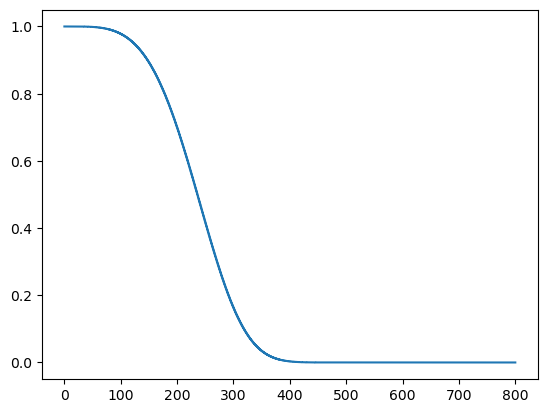

In [12]:
idx = 0
time_grid = np.linspace(0, 800, 1000)
sf_true = sim.calc_sf(ds['X_num_test'][idx], ds['X_cat_test'][idx], time_grid)
fig, ax = plt.subplots()
ax.step(time_grid, sf_true, where='post')
plt.show()

In [13]:
sdpm_list = []
rsf_list = []
for ev_rate in ev_rate_list:
    ds, sim = gen_ds(DS, ev_rate)
    sdpm_list.append(train_sdpm(ds, config_sdpm, SEED))
    rsf_list.append(train_rsf(ds, config_rsf, time_grid))

In [33]:
idx = 0

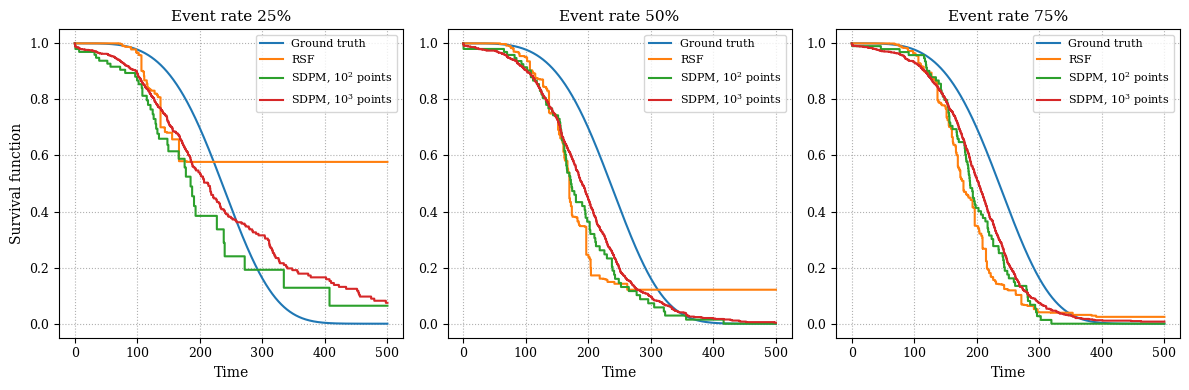

In [34]:
time_grid = np.linspace(0, 500, 1000)
fig, ax = draw_plots(ds, idx, sim, sdpm_list, rsf_list, [100, 1000], time_grid)
plt.show()

In [28]:
fig.savefig('SF_ablation.png', dpi=300)

In [14]:
def KS_dist(s1, s2):
    return np.max(np.abs(s1 - s2), axis=1)

def VM_dist(s1, s2, time_grid):
    diff = np.diff(time_grid, append=time_grid[-1])
    return np.sum((s1 - s2) ** 2 * diff, axis=-1)

In [22]:
def calc_diff_all(times_list, time_grid):
    results = {
        'ev_rate': [],
        'KS': [],
        'VM': [],
        'model_name': [],
    }
    for ev in ev_rate_list:
        ds, sim = gen_ds(DS, ev)
        sdpm = train_sdpm(ds, config_sdpm, 123)
        rsf = train_rsf(ds, config_rsf, time_grid)

        sf_true = sim.calc_sf(ds['X_num_test'], ds['X_cat_test'], time_grid)
        sf_rsf = rsf.predict(ds['X_num_test'], ds['X_cat_test'])
        results['ev_rate'].append(ev)
        results['model_name'].append('RSF')
        results['KS'].append(np.mean(KS_dist(sf_true, sf_rsf)))
        results['VM'].append(np.mean(VM_dist(sf_true, sf_rsf, time_grid)))
        for t_n in time_n_list:
            sf_sdpm = sdpm.predict_sf(ds['X_num_test'], ds['X_cat_test'], time_grid=time_grid, times_n=t_n)
            results['ev_rate'].append(ev)
            results['model_name'].append(f'SDPM {t_n}')
            results['KS'].append(np.mean(KS_dist(sf_true, sf_sdpm)))
            results['VM'].append(np.mean(VM_dist(sf_true, sf_sdpm, time_grid)))

    return pd.DataFrame(results)

In [23]:
time_grid = np.linspace(0, 800, 1000)
time_n_list = [100, 500, 2000]

df_res = calc_diff_all(time_n_list, time_grid)

In [24]:
final_table = pd.pivot_table(df_res, values=['KS', 'VM'], index=['model_name'], columns=['ev_rate'], aggfunc=['mean'])
final_table

mean                                                     
                  KS                             VM                      
ev_rate         0.25      0.50      0.75       0.25       0.50       0.75
model_name                                                               
RSF         0.442357  0.336743  0.300772  57.619962  24.748671  19.713432
SDPM 100    0.444750  0.353872  0.205895  40.562542  22.967262   6.887659
SDPM 2000   0.310368  0.285367  0.168311  20.115498  17.886072   6.100745
SDPM 500    0.345563  0.301101  0.180286  22.148258  18.864694   6.624142

In [25]:
print(final_table.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{6}{r}{mean} \\
 & \multicolumn{3}{r}{KS} & \multicolumn{3}{r}{VM} \\
ev_rate & 0.250000 & 0.500000 & 0.750000 & 0.250000 & 0.500000 & 0.750000 \\
model_name &  &  &  &  &  &  \\
\midrule
RSF & 0.442357 & 0.336743 & 0.300772 & 57.619962 & 24.748671 & 19.713432 \\
SDPM 100 & 0.444750 & 0.353872 & 0.205895 & 40.562542 & 22.967262 & 6.887659 \\
SDPM 2000 & 0.310368 & 0.285367 & 0.168311 & 20.115498 & 17.886072 & 6.100745 \\
SDPM 500 & 0.345563 & 0.301101 & 0.180286 & 22.148258 & 18.864694 & 6.624142 \\
\bottomrule
\end{tabular}

